In [4]:
import pandas as pd

# Path to your Excel file
file_path = "RAW_DATA_IMPORT(1).xlsx"

# Load all sheets into separate DataFrames
sheets = pd.ExcelFile(file_path)

# Create DataFrames for each sheet
customers_df = pd.read_excel(file_path, sheet_name='Customers')
risk_df = pd.read_excel(file_path, sheet_name='Risk')
customer_assets_df = pd.read_excel(file_path, sheet_name='Customer_Assets')
asset_objectives_df = pd.read_excel(file_path, sheet_name='Asset_Objectives')
customer_answers_df = pd.read_excel(file_path, sheet_name='Customer_Answers')
questions_df = pd.read_excel(file_path, sheet_name='Questions')
answers_df = pd.read_excel(file_path, sheet_name='Answers')
risk_profile_df = pd.read_excel(file_path, sheet_name='Risk_Profile')
asset_classes_df = pd.read_excel(file_path, sheet_name='Asset_Classes')
potential_funds_df = pd.read_excel(file_path, sheet_name='Potential_Funds')
fund_targets_df = pd.read_excel(file_path, sheet_name='Fund_Targets')
fund_assets_df = pd.read_excel(file_path, sheet_name='Fund_Assets')
customer_funds_df = pd.read_excel(file_path, sheet_name='Customer_Funds')
engagement_frequency_df = pd.read_excel(file_path, sheet_name='Engagement_Frequency')
engagement_type_df = pd.read_excel(file_path, sheet_name='Engagement_Type')
customer_engagement_type_df = pd.read_excel(file_path, sheet_name='Customer_Engagement_Preferences')
# Optional: print first few rows to check
print(customers_df.head())
print(risk_df.head())


   customer_ID Contact_Last_Name Contact_First_Name  \
0            1            Chaney             Jemima   
1            2           Collins               Colt   
2            3          Crawford             Glenna   
3            4            Fisher             Sophia   
4            5          Gonzales               Evan   

                          Street       City Cust_State    Zip        Country  \
0               5584 Orci Street  Lexington    Alabama  36751  United States   
1     P.O. Box 643, 8508 At, St.     Boston    Alabama  25388  United States   
2  P.O. Box 890, 8204 Lectus Rd.  Milwaukee    Alabama  33343  United States   
3        Ap #274-5091 Vel Avenue      Salem    Alabama  90464  United States   
4            798-923 Ante Street    Olympia    Alabama  82930  United States   

   Age Marital_Status  Gender  Num_Dependants  
0   65        Married    Male               0  
1   65        Married    Male               0  
2   65            NaN    Male               

In [5]:
print(customer_assets_df.head())

   Customer_Asset_Id  Customer_ID  Asset_Objective_ID         Total
0                  1            1                   1  1.157902e+05
1                  2            2                   1  1.991070e+06
2                  3            3                   1  1.569350e+06
3                  4            4                   1  2.162568e+06
4                  5            5                   1  1.366450e+06


In [5]:
# -------------------------------
# 2. Customers + Risk
# -------------------------------
cust_risk = customers_df.merge(
    risk_df, left_on="customer_ID", right_on="CUST_ID", how="left"
)

# -------------------------------
# 3. Customer Assets Pivot
# -------------------------------
cust_assets = customer_assets_df.merge(
    asset_objectives_df, on="Asset_Objective_ID", how="left"
)

cust_assets_pivot = cust_assets.pivot_table(
    index="Customer_ID",
    columns="Asset_Objective_Name",
    values="Total",
    aggfunc="sum",
    fill_value=0
).reset_index()

# -------------------------------
# 4. Engagement Preferences
# -------------------------------
# Standardize naming for merge keys
customer_engagement_type_df = customer_engagement_type_df.rename(
    columns={"Engagement_Type_ID": "Engagement_Type_Id"}
)

cust_engagement = (
    customer_engagement_type_df
    .merge(engagement_type_df, on="Engagement_Type_Id", how="left")
    .merge(engagement_frequency_df, on="Frequency_Id", how="left")
)

cust_engagement_summary = (
    cust_engagement.groupby("Customer_ID")
    .agg({
        "Engagement_Type_Name": lambda x: ", ".join(x.dropna().unique()),
        "Frequency_Name": lambda x: ", ".join(x.dropna().unique())
    })
    .reset_index()
)

# -------------------------------
# 5. Build Final Master DataFrame
# -------------------------------
master_df = cust_risk.merge(
    cust_assets_pivot, left_on="customer_ID", right_on="Customer_ID", how="left"
).merge(
    cust_engagement_summary, left_on="customer_ID", right_on="Customer_ID", how="left"
)

# Drop duplicate join cols
master_df = master_df.drop(columns=["CUST_ID", "Customer_ID_x", "Customer_ID_y"], errors="ignore")

# -------------------------------
# 6. Inspect Result
# -------------------------------
pd.set_option("display.max_columns", None)
print(master_df.head())


KeyError: 'Frequency_Id'

In [6]:
import pandas as pd

# -------------------------------
# 1. Load Excel & All Sheets
# -------------------------------
file_path = "RAW_DATA_IMPORT(1).xlsx"
xls = pd.ExcelFile(file_path)

customers_df = pd.read_excel(file_path, sheet_name='Customers')
risk_df = pd.read_excel(file_path, sheet_name='Risk')
customer_assets_df = pd.read_excel(file_path, sheet_name='Customer_Assets')
asset_objectives_df = pd.read_excel(file_path, sheet_name='Asset_Objectives')
customer_answers_df = pd.read_excel(file_path, sheet_name='Customer_Answers')
questions_df = pd.read_excel(file_path, sheet_name='Questions')
answers_df = pd.read_excel(file_path, sheet_name='Answers')
risk_profile_df = pd.read_excel(file_path, sheet_name='Risk_Profile')
asset_classes_df = pd.read_excel(file_path, sheet_name='Asset_Classes')
potential_funds_df = pd.read_excel(file_path, sheet_name='Potential_Funds')
fund_targets_df = pd.read_excel(file_path, sheet_name='Fund_Targets')
fund_assets_df = pd.read_excel(file_path, sheet_name='Fund_Assets')
customer_funds_df = pd.read_excel(file_path, sheet_name='Customer_Funds')
engagement_frequency_df = pd.read_excel(file_path, sheet_name='Engagement_Frequency')
engagement_type_df = pd.read_excel(file_path, sheet_name='Engagement_Type')
customer_engagement_type_df = pd.read_excel(file_path, sheet_name='Customer_Engagement_Preferences')

# -------------------------------
# 2. Customers + Risk
# -------------------------------
cust_risk = customers_df.merge(
    risk_df, left_on="customer_ID", right_on="CUST_ID", how="left"
)

# -------------------------------
# 3. Customer Assets Pivot
# -------------------------------
cust_assets = customer_assets_df.merge(
    asset_objectives_df, on="Asset_Objective_ID", how="left"
)

cust_assets_pivot = cust_assets.pivot_table(
    index="Customer_ID",
    columns="Asset_Objective_Name",
    values="Total",
    aggfunc="sum",
    fill_value=0
).reset_index()

# -------------------------------
# 4. Engagement Preferences
# -------------------------------
# Standardize naming for merge keys
customer_engagement_type_df = customer_engagement_type_df.rename(
    columns={
        "Engagement_Type_ID": "Engagement_Type_Id",
        "Frequency_ID": "Frequency_Id"
    }
)

cust_engagement = (
    customer_engagement_type_df
    .merge(engagement_type_df, on="Engagement_Type_Id", how="left")
    .merge(engagement_frequency_df, on="Frequency_Id", how="left")
)

cust_engagement_summary = (
    cust_engagement.groupby("Customer_ID")
    .agg({
        "Engagement_Type_Name": lambda x: ", ".join(x.dropna().unique()),
        "Frequency_Name": lambda x: ", ".join(x.dropna().unique())
    })
    .reset_index()
)

# -------------------------------
# 5. Build Final Master DataFrame
# -------------------------------
master_df = cust_risk.merge(
    cust_assets_pivot, left_on="customer_ID", right_on="Customer_ID", how="left"
).merge(
    cust_engagement_summary, left_on="customer_ID", right_on="Customer_ID", how="left"
)

# Drop duplicate join cols
master_df = master_df.drop(columns=["CUST_ID", "Customer_ID_x", "Customer_ID_y"], errors="ignore")

# -------------------------------
# 6. Inspect Result
# -------------------------------
pd.set_option("display.max_columns", None)
print(master_df.head())


   customer_ID Contact_Last_Name Contact_First_Name  \
0            1            Chaney             Jemima   
1            2           Collins               Colt   
2            3          Crawford             Glenna   
3            4            Fisher             Sophia   
4            5          Gonzales               Evan   

                          Street       City Cust_State    Zip        Country  \
0               5584 Orci Street  Lexington    Alabama  36751  United States   
1     P.O. Box 643, 8508 At, St.     Boston    Alabama  25388  United States   
2  P.O. Box 890, 8204 Lectus Rd.  Milwaukee    Alabama  33343  United States   
3        Ap #274-5091 Vel Avenue      Salem    Alabama  90464  United States   
4            798-923 Ante Street    Olympia    Alabama  82930  United States   

   Age Marital_Status  Gender  Num_Dependants  RISK_SCORE  Family Planning  \
0   65        Married    Male               0        2.50     8.950859e+05   
1   65        Married    Male   

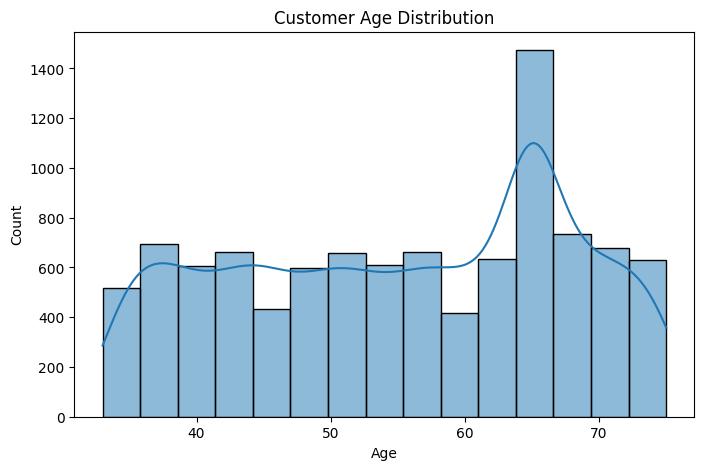

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(master_df['Age'], bins=15, kde=True)
plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()


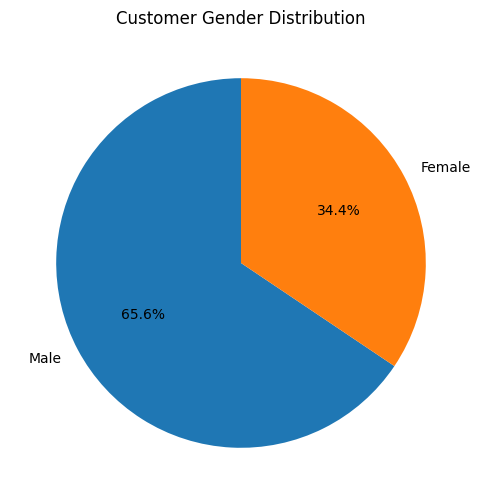

In [8]:
plt.figure(figsize=(6,6))
master_df['Gender'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90)
plt.title("Customer Gender Distribution")
plt.ylabel("")
plt.show()


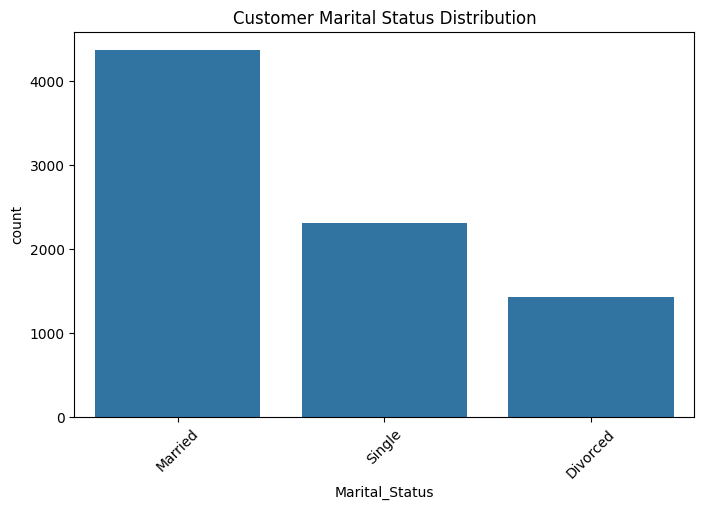

In [9]:
plt.figure(figsize=(8,5))
sns.countplot(x="Marital_Status", data=master_df, order=master_df["Marital_Status"].value_counts().index)
plt.title("Customer Marital Status Distribution")
plt.xticks(rotation=45)
plt.show()


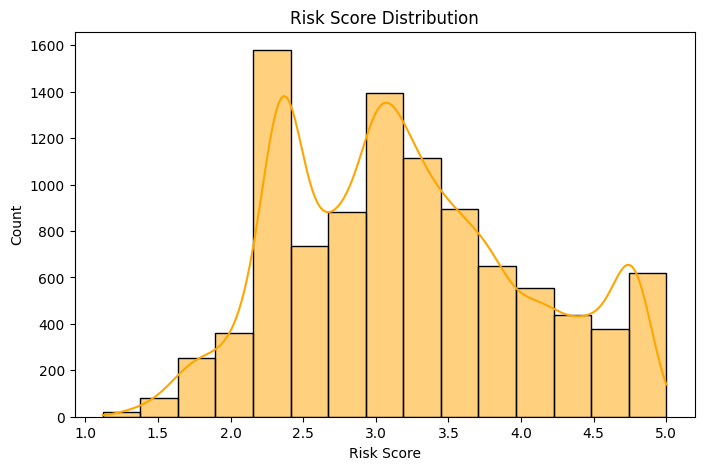

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(master_df['RISK_SCORE'], bins=15, kde=True, color="orange")
plt.title("Risk Score Distribution")
plt.xlabel("Risk Score")
plt.show()


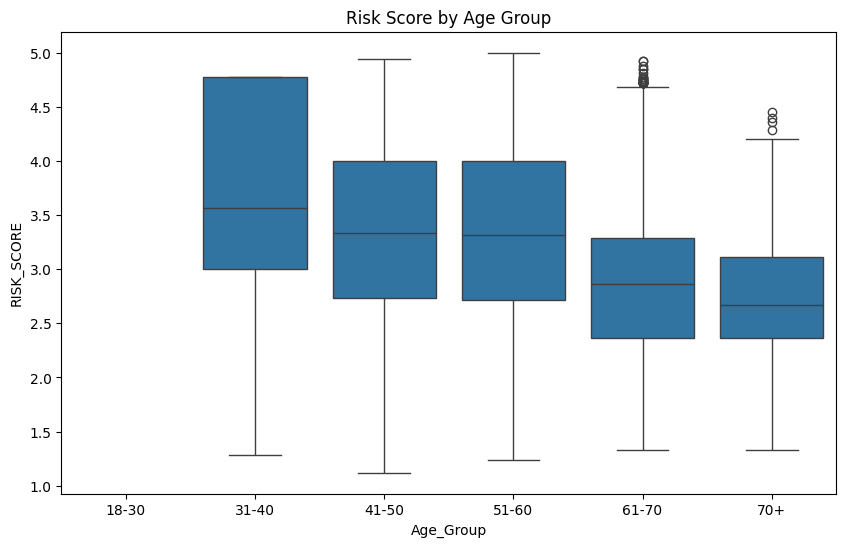

In [11]:
master_df['Age_Group'] = pd.cut(master_df['Age'], bins=[18,30,40,50,60,70,100], labels=["18-30","31-40","41-50","51-60","61-70","70+"])

plt.figure(figsize=(10,6))
sns.boxplot(x="Age_Group", y="RISK_SCORE", data=master_df)
plt.title("Risk Score by Age Group")
plt.show()


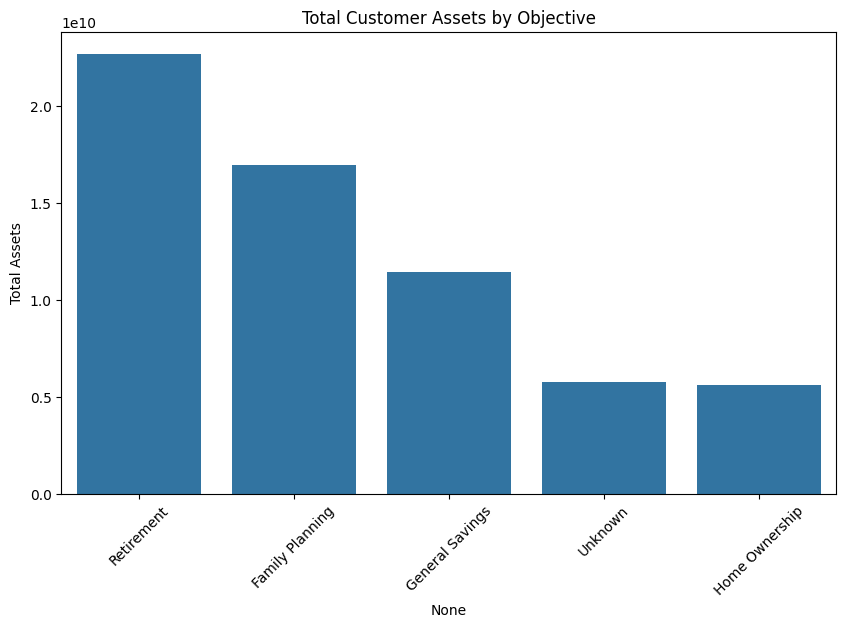

In [12]:
asset_cols = [col for col in master_df.columns if col in asset_objectives_df['Asset_Objective_Name'].values]

asset_sums = master_df[asset_cols].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=asset_sums.index, y=asset_sums.values)
plt.title("Total Customer Assets by Objective")
plt.ylabel("Total Assets")
plt.xticks(rotation=45)
plt.show()


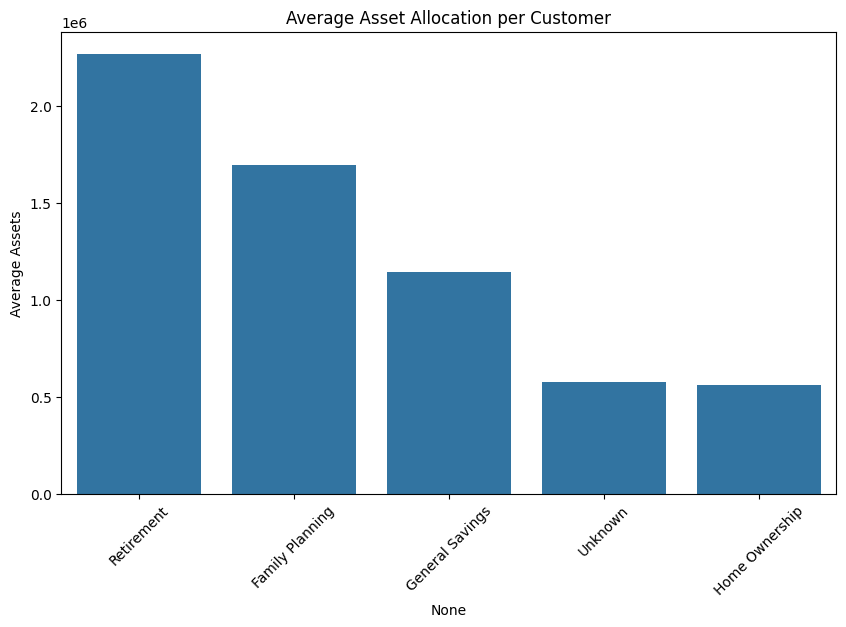

In [13]:
asset_means = master_df[asset_cols].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=asset_means.index, y=asset_means.values)
plt.title("Average Asset Allocation per Customer")
plt.ylabel("Average Assets")
plt.xticks(rotation=45)
plt.show()


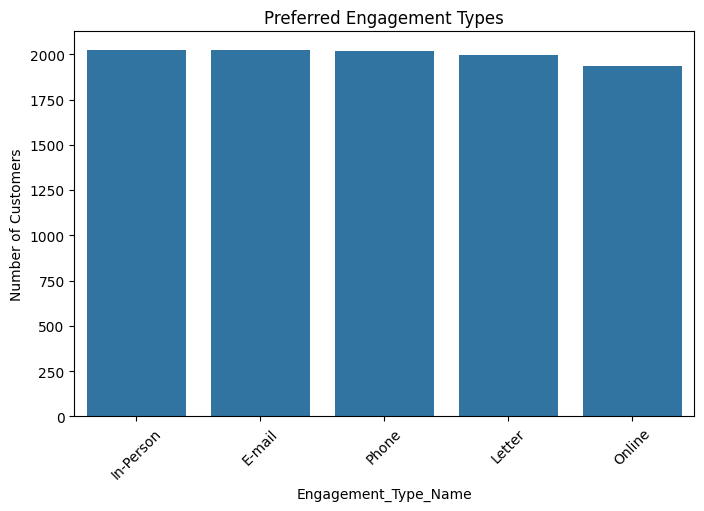

In [14]:
engagement_counts = master_df['Engagement_Type_Name'].str.split(", ").explode().value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=engagement_counts.index, y=engagement_counts.values)
plt.title("Preferred Engagement Types")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


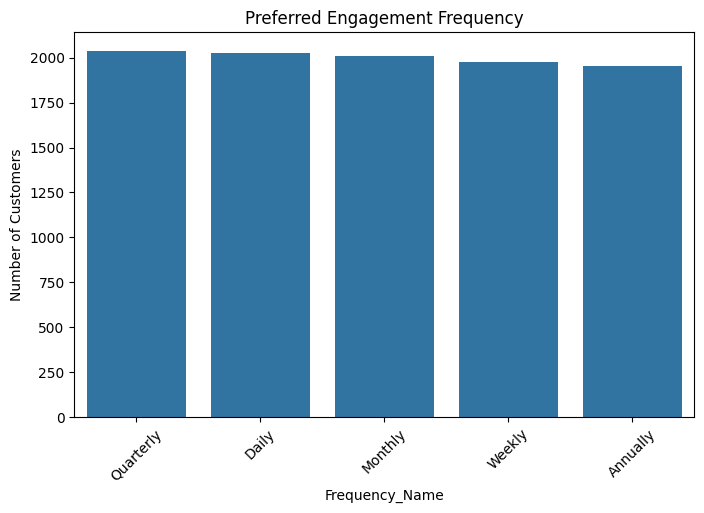

In [15]:
freq_counts = master_df['Frequency_Name'].str.split(", ").explode().value_counts()

plt.figure(figsize=(8,5))
sns.barplot(x=freq_counts.index, y=freq_counts.values)
plt.title("Preferred Engagement Frequency")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()


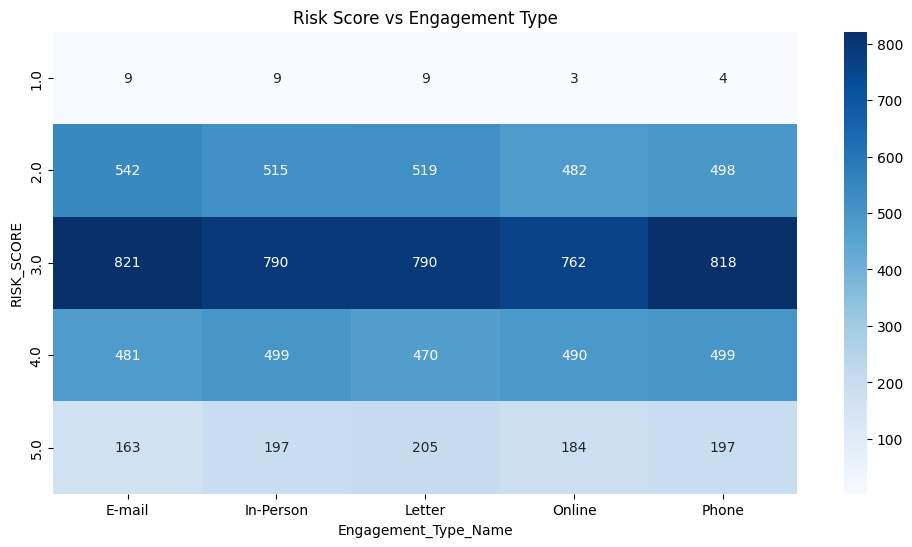

In [16]:
cross_tab = pd.crosstab(master_df['RISK_SCORE'].round(), master_df['Engagement_Type_Name'])

plt.figure(figsize=(12,6))
sns.heatmap(cross_tab, cmap="Blues", annot=True, fmt="d")
plt.title("Risk Score vs Engagement Type")
plt.show()


D:\Users\Student13\AppData\Local\Temp\1\ipykernel_10464\3019474377.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_asset = master_df.groupby('Age_Group')[asset_cols].mean()


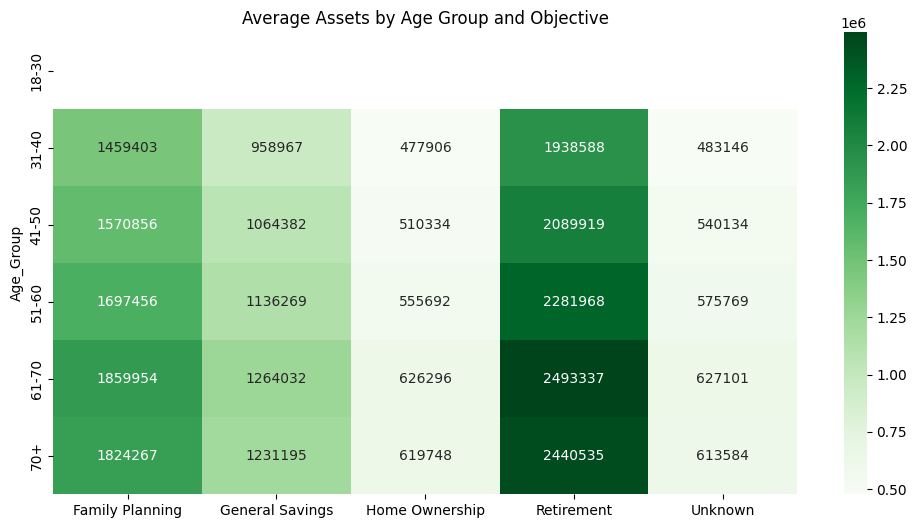

In [17]:
age_asset = master_df.groupby('Age_Group')[asset_cols].mean()

plt.figure(figsize=(12,6))
sns.heatmap(age_asset, cmap="Greens", annot=True, fmt=".0f")
plt.title("Average Assets by Age Group and Objective")
plt.show()


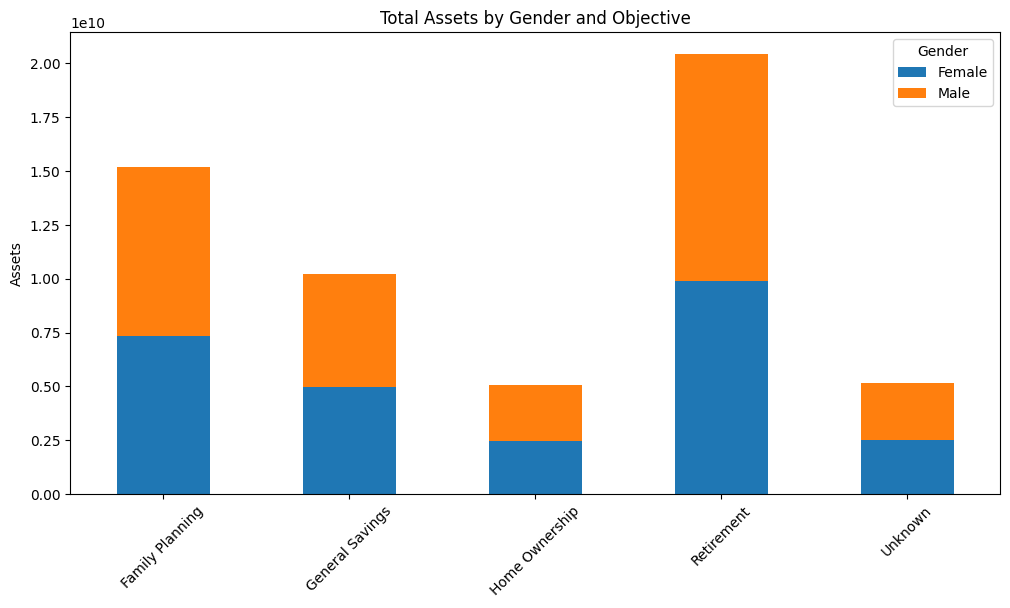

In [20]:
asset_by_gender = master_df.groupby("Gender")[asset_cols].sum()

asset_by_gender.T.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Total Assets by Gender and Objective")
plt.ylabel("Assets")
plt.xticks(rotation=45)
plt.show()


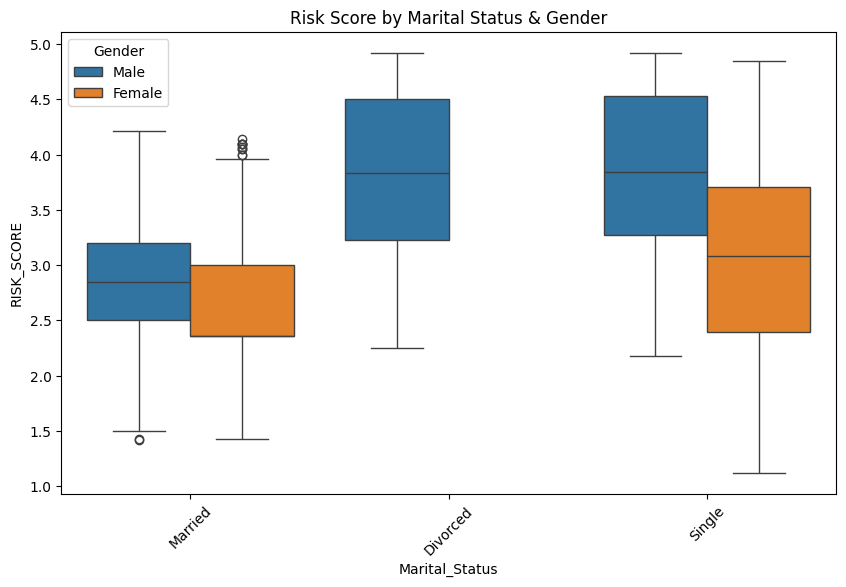

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(x="Marital_Status", y="RISK_SCORE", hue="Gender", data=master_df)
plt.title("Risk Score by Marital Status & Gender")
plt.xticks(rotation=45)
plt.show()


D:\Users\Student13\AppData\Local\Temp\1\ipykernel_10464\2745802504.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eng_risk = master_df.groupby(["Engagement_Type_Name","Risk_Bucket"]).size().unstack(fill_value=0)


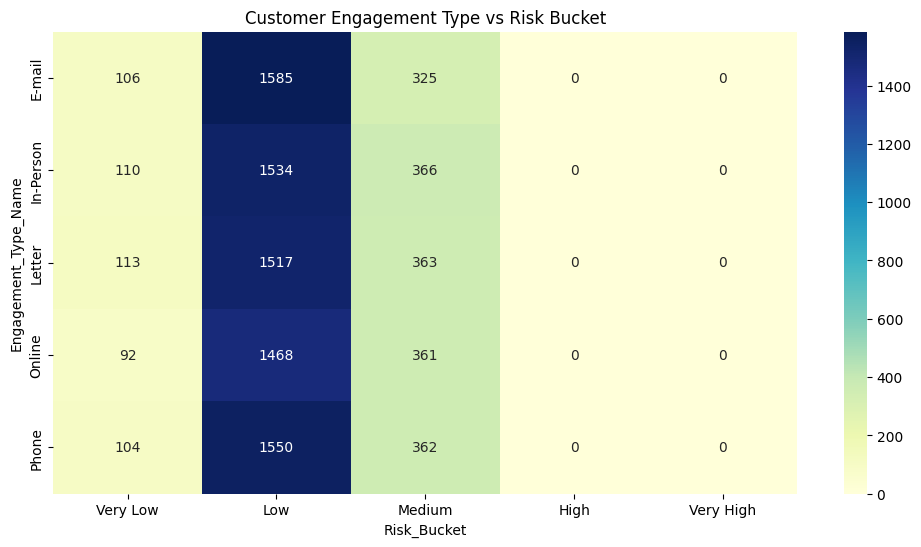

In [23]:
eng_risk = master_df.groupby(["Engagement_Type_Name","Risk_Bucket"]).size().unstack(fill_value=0)

plt.figure(figsize=(12,6))
sns.heatmap(eng_risk, annot=True, fmt="d", cmap="YlGnBu")
plt.title("Customer Engagement Type vs Risk Bucket")
plt.show()
